/tmp/ipykernel_1536225/2126649728.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


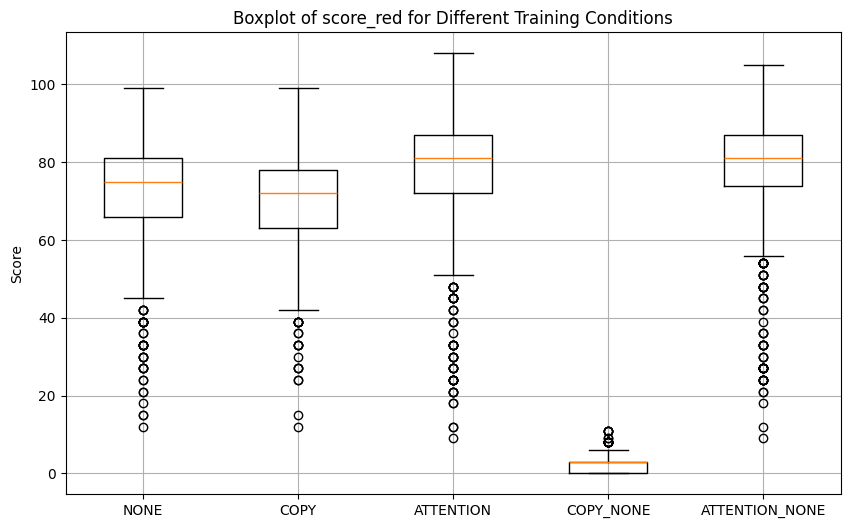

Two-sample t-test between NONE and COPY: t-statistic = 2.821, p-value = 0.005
Two-sample t-test between NONE and ATTENTION: t-statistic = -9.002, p-value = 0.000
Two-sample t-test between COPY and ATTENTION: t-statistic = -12.054, p-value = 0.000
Two-sample t-test between COPY and COPY_NONE: t-statistic = 176.573, p-value = 0.000
Two-sample t-test between ATTENTION and ATTENTION_NONE: t-statistic = -0.819, p-value = 0.413


In [ ]:
"""
iteration,steps,env_steps,internal_ticks,score_red
1,79,79,600,81.0
2,68,68,600,105.0
3,72,72,600,93.0
4,70,70,600,105.0
5,80,80,600,87.0
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

none_none = pd.read_csv('none_none_1_0.csv')
copy_copy = pd.read_csv('copy_copy_1_0.csv')
copy_none = pd.read_csv('copy_none_1_0.csv')
attention_attention = pd.read_csv('attention_attention_1_0.csv')
attention_none = pd.read_csv('attention_none_1_0.csv')


# Create boxplots for score_red
plt.figure(figsize=(10, 6))
plt.boxplot(
    [none_none['score_red'], copy_copy['score_red'], attention_attention['score_red'], copy_none['score_red'], attention_none['score_red']],
    labels=['NONE', 'COPY', 'ATTENTION', 'COPY_NONE', 'ATTENTION_NONE']) 
plt.title('Boxplot of score_red for Different Training Conditions')
plt.ylabel('Score')
plt.grid(True)
plt.show()

from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(none_none['score_red'], copy_copy['score_red'])
print(f'Two-sample t-test between NONE and COPY: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')

t_stat, p_value = ttest_ind(none_none['score_red'], attention_attention['score_red'])
print(f'Two-sample t-test between NONE and ATTENTION: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')

t_stat, p_value = ttest_ind(copy_copy['score_red'], attention_attention['score_red'])
print(f'Two-sample t-test between COPY and ATTENTION: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')

t_stat, p_value = ttest_ind(copy_copy['score_red'], copy_none['score_red'])
print(f'Two-sample t-test between COPY and COPY_NONE: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')

t_stat, p_value = ttest_ind(attention_attention['score_red'], attention_none['score_red'])
print(f'Two-sample t-test between ATTENTION and ATTENTION_NONE: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')

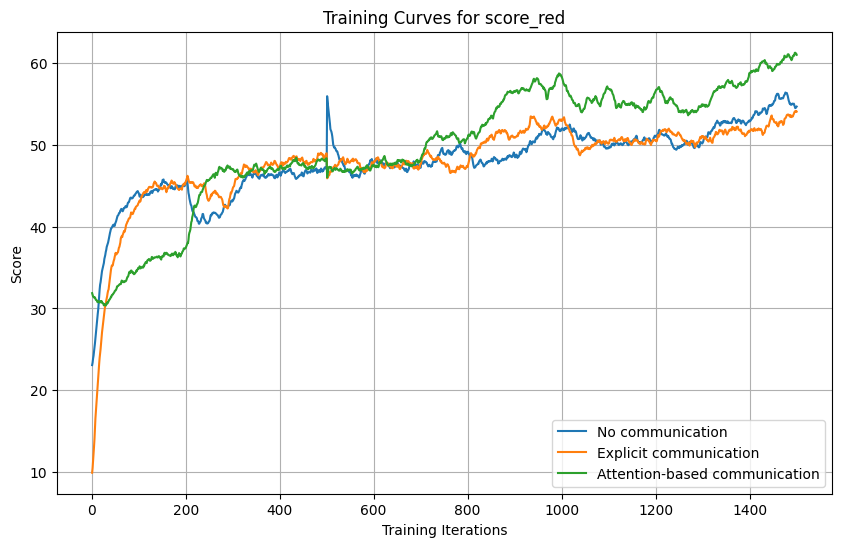

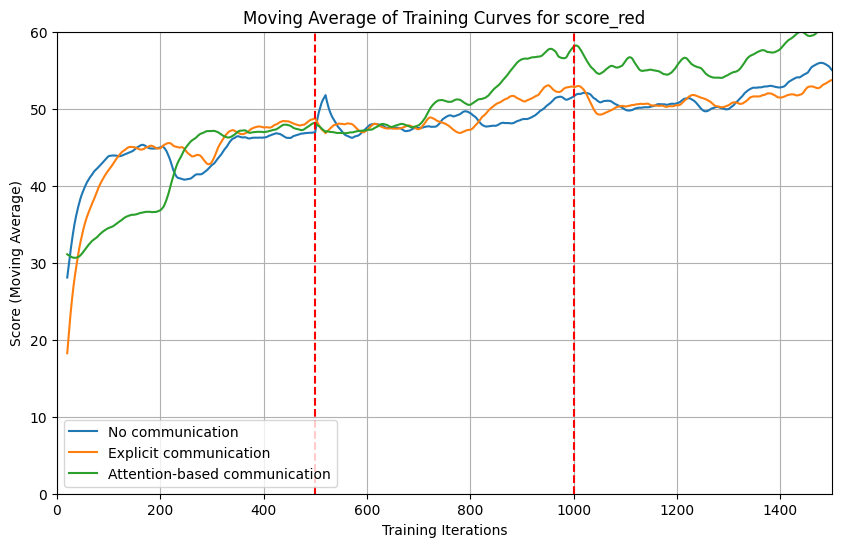

In [18]:
training_none = pd.concat([pd.read_csv('training_none_0_500.csv'), pd.read_csv('training_none_500_1500.csv')])
training_copy = pd.concat([pd.read_csv('training_copy_0_500.csv'), pd.read_csv('training_copy_500_1500.csv')])
training_attention = pd.concat([pd.read_csv('training_attention_0_500.csv'), pd.read_csv('training_attention_500_1500.csv')])

# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(training_none['training_iteration'], training_none['env_runners/red_team_score_mean'], label='No communication')
plt.plot(training_copy['training_iteration'], training_copy['env_runners/red_team_score_mean'], label='Explicit communication')
plt.plot(training_attention['training_iteration'], training_attention['env_runners/red_team_score_mean'], label='Attention-based communication')
plt.title('Training Curves for score_red')
plt.xlabel('Training Iterations')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# Plot moving average of training curves
def moving_average(data, window_size):
    return data.rolling(window=window_size).mean()
window_size = 20
plt.figure(figsize=(10, 6))
plt.plot(training_none['training_iteration'], moving_average(training_none['env_runners/red_team_score_mean'], window_size), label='No communication')
plt.plot(training_copy['training_iteration'], moving_average(training_copy['env_runners/red_team_score_mean'], window_size), label='Explicit communication')
plt.plot(training_attention['training_iteration'], moving_average(training_attention['env_runners/red_team_score_mean'], window_size), label='Attention-based communication')
plt.axvline(x=500, color='red', linestyle='--')
plt.axvline(x=1000, color='red', linestyle='--')
plt.xlim(0, 1500)
plt.ylim(0, 60)
plt.title('Moving Average of Training Curves for score_red')
plt.xlabel('Training Iterations')
plt.ylabel('Score (Moving Average)')
plt.legend()
plt.grid(True)
plt.show()